# 1. Define QUBO matrix

In [1]:
import sys
import numpy as np


sys.path.append("..")
from src.qubo_windfarm_layout.model import get_farm_area, get_mask, build_qubo_from_wake_matrix_optimized, build_wake_loss_matrix_optimized, build_wake_loss_matrix_optimized, load_wake_loss_data
from src.qubo_windfarm_layout.visualization import plot_selected_layout
from src.solvers.utils import get_invalid_pairs
from src.solvers.ortools import solve_wflo_cpsat
from src.solvers.utils import save_benchmark_layout

In [2]:
# Variables
GRID_RESOLUTION = 100 # m
MIN_DISTANCE = 396  # 2 * 198 m
SPARSITY = None # percentile di wake interactions da droppare

# Get candidates
polygons, farm_area = get_farm_area()
X, Y, mask = get_mask(farm_area=farm_area, grid_resolution=GRID_RESOLUTION)

candidate_locations = np.column_stack([
    X[mask],
    Y[mask],
])

print(f"Filtered candidates shape {candidate_locations.shape}")

# Invalid pairs constraint
invalid_pairs = get_invalid_pairs(candidate_locations=candidate_locations, min_distance=MIN_DISTANCE)

Filtered candidates shape (3622, 2)


In [3]:
# Matrix definition
# build_wake_loss_matrix_optimized(
#     candidate_locations,
#     grid_resolution=GRID_RESOLUTION,
#     output_path=f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz"
# )

wake_loss = load_wake_loss_data(f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz")
wake_loss_matrix = wake_loss["wake_loss_matrix"]
A0 = wake_loss["A0"]

Q, offset = build_qubo_from_wake_matrix_optimized(
    wake_loss_matrix,
    invalid_pairs,
    A0,
    n_turbines=81,
    lambda_cardinality=32000,
    lambda_spacing=5500
)

In [ ]:
import numpy as np


def sparsify_wake_by_percentile(
    wake_loss_matrix,
    percentile,
    n_turbines=81,
):  
    if not percentile:
        return None
    
    L = np.asarray(wake_loss_matrix, dtype=float)

    # Consideriamo ogni interazione una sola volta
    triu_idx = np.triu_indices_from(L, k=1)
    losses = L[triu_idx]

    # Threshold corrispondente al percentile scelto
    threshold = np.percentile(losses, percentile)

    # Drop delle interazioni deboli
    L_sparse = L.copy()
    L_sparse[L_sparse < threshold] = 0.0

    np.fill_diagonal(L_sparse, 0.0)

    # Statistiche
    total_pairs = len(losses)

    retained_pairs = np.count_nonzero(
        L_sparse[triu_idx]
    )

    density = retained_pairs / total_pairs

    # Worst-case error bound per un layout di K turbine
    max_active_pairs = (
        n_turbines * (n_turbines - 1) // 2
    )

    max_error_bound = (
        max_active_pairs * threshold
    )

    return L_sparse, {
        "percentile": percentile,
        "threshold": threshold,
        "retained_pairs": retained_pairs,
        "total_pairs": total_pairs,
        "density": density,
        "max_error_bound": max_error_bound,
    }

L_sparse, info = sparsify_wake_by_percentile(
    wake_loss_matrix,
    percentile=SPARSITY,
)

print(info)

In [ ]:
feasible = 20547255
26117583 - feasible

In [ ]:
if SPARSITY:
    wake_loss_matrix = L_sparse 
    print("Matrice ridotta")

# 2. Solvers

## 2.1 OR Tools - CPSAT

In [ ]:
time_limit_s = 60*30

z_solution, solver = solve_wflo_cpsat(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
    num_workers=8,
)

selected_locations = candidate_locations[
    z_solution.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations)

save_benchmark_layout(
    selected_locations=selected_locations,
    solver_name="cpsat",
    filename=f"cpsat_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.2 OR Tools - SCIP

In [ ]:
from src.solvers.ortools import solve_wflo_gscip

time_limit_s = 60*60

z_solution_scip, _ = solve_wflo_gscip(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
)

selected_locations_scip = candidate_locations[
    z_solution_scip.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations_scip)

save_benchmark_layout(
    selected_locations=selected_locations_scip,
    solver_name="scip",
    filename=f"scip_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.3 D-Wave Simulated Annealing

In [ ]:
from src.solvers.dwave import solve_wflo_dwave
from src.solvers.utils import save_benchmark_layout

NUM_READS = 1000
NUM_SWEEPS = 40000

z_dwave, sampleset = solve_wflo_dwave(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    Q=Q,
    n_turbines=81,
    sampler_type="simulated_annealing",
    num_reads=NUM_READS,   # Dimezzare read e quadruplicare sweep costa lo stesso tempo
    num_sweeps=NUM_SWEEPS, # num_sweeps >= 10 x n variables
    seed=42,
)
selected_locations_dwave = candidate_locations[z_dwave.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_dwave)
save_benchmark_layout(
    selected_locations=selected_locations_dwave,
    solver_name="dwave_sa",
    filename=f"dwave_sa_{GRID_RESOLUTION}_{NUM_READS}reads_{NUM_SWEEPS}sweeps.yaml",
    grid_resolution=GRID_RESOLUTION,
)

In [ ]:
f"dwave_sa_{GRID_RESOLUTION}_{NUM_READS}reads_{NUM_SWEEPS}sweeps.yaml"

## 2.4 SQBM+

In [ ]:
from src.solvers.sqbm import SQBMClient, solve_wflo_sqbm

SQBM_HOST = "20.229.234.199"
SQBM_PORT = 8000

client = SQBMClient(host=SQBM_HOST, port=SQBM_PORT, timeout=1200, problem_format="hdf5")

print("Health check:", client.health_check())
print("Version:     ", client.version())

In [ ]:
TIMEOUT = 20
ALGO = 0

solution, sqbm_result = solve_wflo_sqbm(
    wake_loss_matrix,
    invalid_pairs,
    Q,
    host=SQBM_HOST,
    port=SQBM_PORT,
    timeout=TIMEOUT,
    algo=ALGO,
)
selected_locations_sqbm = candidate_locations[solution.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_sqbm)
save_benchmark_layout(
    selected_locations=selected_locations_sqbm,
    solver_name="sqbm",
    filename=f"sqbm_{GRID_RESOLUTION}_{ALGO}algo_{TIMEOUT}s.yaml",
    grid_resolution=GRID_RESOLUTION,
)

## 2.5 Gurobi

In [ ]:
# import os
# from dotenv import load_dotenv
# import gurobipy as gp

# load_dotenv()

# env = gp.Env(
#     params={
#         "WLSACCESSID": os.getenv("WLSACCESSID"),
#         "WLSSECRET": os.getenv("WLSSECRET"),
#         "LICENSEID": int(os.getenv("LICENSEID")),
#     }
# )

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2864483
WLS license 2864483 - registered to Accenture GmbH (Germany)


In [ ]:
# import numpy as np
# import scipy.sparse as sp
# import gurobipy as gp
# from gurobipy import GRB


# def solve_wflo_gurobi(
#     wake_loss_matrix,
#     invalid_pairs,
#     n_turbines=81,
#     warm_start=None,
#     time_limit=None,
#     mip_gap=1e-3,
#     verbose=True,
# ):
#     L = np.asarray(wake_loss_matrix, dtype=float)

#     if L.ndim != 2 or L.shape[0] != L.shape[1]:
#         raise ValueError("wake_loss_matrix deve essere quadrata.")

#     n = L.shape[0]

#     invalid_pairs = np.asarray(invalid_pairs, dtype=int)

#     model = gp.Model("wflo", env=env)

#     model.Params.OutputFlag = 1 if verbose else 0
#     model.Params.MIPGap = mip_gap
#     model.Params.NonConvex = 2

#     model.Params.Threads = 1
#     model.Params.NodefileStart = 0.5
#     model.Params.NodefileDir = "/tmp"
#     model.Params.SoftMemLimit = 28

#     if time_limit is not None:
#         model.Params.TimeLimit = time_limit

#     # --------------------------------------------------
#     # Variables
#     # --------------------------------------------------

#     z = model.addMVar(
#         shape=n,
#         vtype=GRB.BINARY,
#         name="z",
#     )

#     # --------------------------------------------------
#     # Warm start
#     # --------------------------------------------------

#     if warm_start is not None:
#         warm_start = np.asarray(
#             warm_start,
#             dtype=float,
#         )

#         if warm_start.shape != (n,):
#             raise ValueError(
#                 f"warm_start deve avere shape ({n},), "
#                 f"ricevuta {warm_start.shape}."
#             )

#         if not np.all(
#             np.isclose(warm_start, 0)
#             | np.isclose(warm_start, 1)
#         ):
#             raise ValueError(
#                 "warm_start deve essere binario."
#             )

#         z.Start = warm_start

#     # --------------------------------------------------
#     # Quadratic objective
#     #
#     # H_wake = sum_{i<j} L_ij z_i z_j
#     # --------------------------------------------------

#     Q = sp.csr_matrix(
#         np.triu(L, k=1)
#     )

#     model.setObjective(
#         z @ Q @ z,
#         GRB.MINIMIZE,
#     )

#     # --------------------------------------------------
#     # Cardinality
#     # --------------------------------------------------

#     model.addConstr(
#         z.sum() == n_turbines,
#         name="cardinality",
#     )

#     # --------------------------------------------------
#     # Spacing constraints
#     #
#     # z_i + z_j <= 1
#     # --------------------------------------------------

#     if len(invalid_pairs) > 0:

#         m = len(invalid_pairs)

#         rows = np.repeat(
#             np.arange(m),
#             2,
#         )

#         cols = invalid_pairs.reshape(-1)

#         data = np.ones(
#             2 * m,
#             dtype=float,
#         )

#         A_spacing = sp.csr_matrix(
#             (data, (rows, cols)),
#             shape=(m, n),
#         )

#         model.addMConstr(
#             A_spacing,
#             z,
#             "<",
#             np.ones(m),
#             name="spacing",
#         )

#     # --------------------------------------------------
#     # Solve
#     # --------------------------------------------------

#     model.optimize()

#     if model.SolCount == 0:
#         raise RuntimeError(
#             f"Gurobi non ha trovato soluzioni. "
#             f"Status: {model.Status}"
#         )

#     # --------------------------------------------------
#     # Results
#     # --------------------------------------------------

#     z_solution = np.rint(
#         z.X
#     ).astype(int)

#     selected_indices = np.flatnonzero(
#         z_solution
#     )

#     return {
#         "z": z_solution,
#         "selected_indices": selected_indices,
#         "objective": float(model.ObjVal),
#         "best_bound": float(model.ObjBound),
#         "mip_gap": float(model.MIPGap),
#         "runtime": float(model.Runtime),
#         "status": model.Status,
#     }

(CVXPY) Sep 17 03:05:30 PM: Encountered unexpected exception importing solver HIGHS:
ImportError('/home/maicolnicolini/code/qubo-wind-farm-layout/.venv/lib/python3.12/site-packages/highspy/_core.cpython-312-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.01
Set parameter NonConvex to value 2
Set parameter Threads to value 1
Set parameter NodefileStart to value 0.5
Set parameter NodefileDir to value "/tmp"
Set parameter SoftMemLimit to value 28
Set parameter TimeLimit to value 1800
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Core(TM) Ultra 7 265H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 1 threads

Non-default parameters:
TimeLimit  1800
SoftMemLimit  28
MIPGap  0.01
NodefileStart  0.5
NonConvex  2
Threads  1

WLS license 2864483 - registered to Accenture GmbH (Germany)
Optimize a model with 68687 rows, 3622 columns and 140994 nonzeros (Min)
Model fingerprint: 0x1817fbf3
Model has 0 linear objective coefficients
Model has 6557631 quadratic objective terms
Variable types: 0 continuous, 3622 integer (3622 binary)
Coefficient statistics:
  Matrix range     

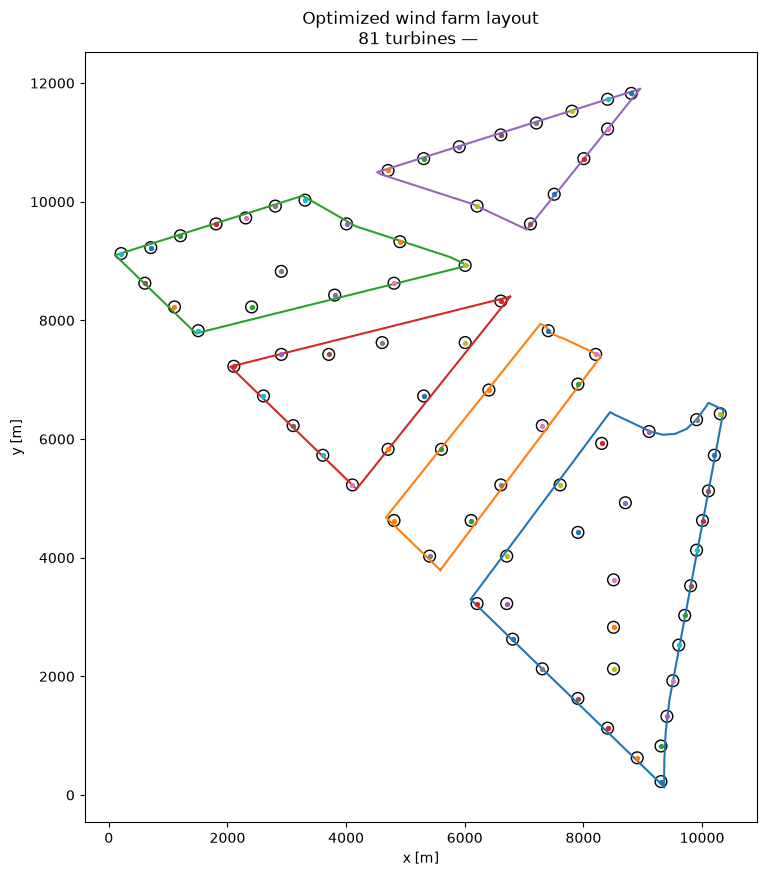

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/gurobi_100_1800s_warmstart_False.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/gurobi_100_1800s_warmstart_False.yaml')

In [6]:
from src.qubo_windfarm_layout.penalties import layout_yaml_to_z
from src.solvers.gurobi import solve_wflo_gurobi
TIMEOUT = 60 * 30
WARMSTART = False

if WARMSTART:
    z_reference, _ = layout_yaml_to_z(
    yaml_path=f"../results/layouts/cpsat_200_3600s.yaml",
    grid_resolution=200,
    )
    warm_start = z_reference
else:
    warm_start = None

result = solve_wflo_gurobi(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    warm_start=warm_start,
    time_limit=TIMEOUT,
    mip_gap=0.01,
)

print("Objective:", result["objective"])
print("Runtime:", result["runtime"])
print("MIP gap:", result["mip_gap"])
print("Best bound:", result["best_bound"])
print("N turbines:", result["z"].sum())

selected_indices = result["selected_indices"]
selected_locations_gurobi = candidate_locations[
    selected_indices
]

plot_selected_layout(selected_locations=selected_locations_gurobi)
save_benchmark_layout(
    selected_locations=selected_locations_gurobi,
    solver_name="gurobi",
    filename=f"gurobi_{GRID_RESOLUTION}_{TIMEOUT}s_warmstart_{WARMSTART}.yaml",
    grid_resolution=GRID_RESOLUTION,
)

In [7]:
from src.qubo_windfarm_layout.penalties import layout_yaml_to_z

GRID_RESOLUTION = 100

z_reference_up, candidate_locations = layout_yaml_to_z(
    yaml_path="/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/gurobi_100_1800s_warmstart_False.yaml",
    grid_resolution = GRID_RESOLUTION
    )

L = np.asarray(wake_loss_matrix, dtype=float)
x = np.asarray(z_reference_up, dtype=float)

# H_wake = sum_{i<j} L_ij x_i x_j
# L è simmetrica, quindi dividiamo per 2
Q = L / 2

upper_bound = float(x @ Q @ x)
print(upper_bound)

859579.5353222268


# Solvers

| Categoria                        | Solver                       |
| -------------------------------- | ---------------------------- |
| Exact / mathematical programming | **Gurobi**                   |
| CP/SAT                           | **OR-Tools CP-SAT**          |
| SCIP                             | **OR-Tools GSCIP**           |
| HiGHS                            | **OR-Tools HiGHS**           |
| Classical hybrid heuristic       | **Hexaly**                   |
| QUBO classical baseline          | **Simulated Annealing**      |
| QUBO classical baseline          | **D-Wave Tabu**              |
| Quantum-inspired                 | **Toshiba SQBM+**            |
| Quantum-inspired                 | **Fujitsu Digital Annealer** |

In [ ]:
# TODO
# Capire se usare base.yaml come starting point (warmstart) può creare dei vantaggi per i solutori quantum